# Overfitting effects on performance metrics

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


Lets make a little test dataset. Our initial function is just a cosine wave with some noise added on top

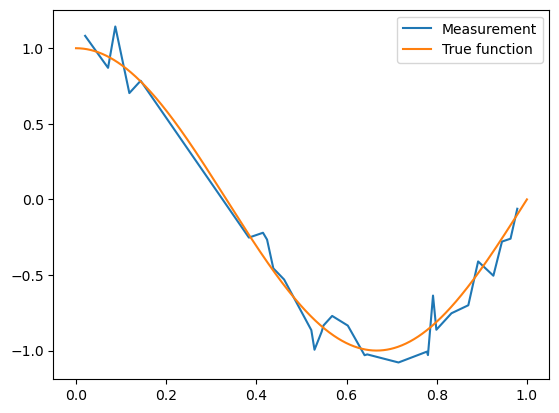

In [2]:
def true_fun(X):
    return np.cos(1.5 * np.pi * X)


np.random.seed(0)

n_samples = 30

X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1

plt.plot(X, y, label="Measurement")
plt.plot(np.linspace(0, 1, 1000), true_fun(np.linspace(0, 1, 1000)), label="True function")
plt.legend()

plt.show()

Training a simple linear regressor on this data does not perform well:

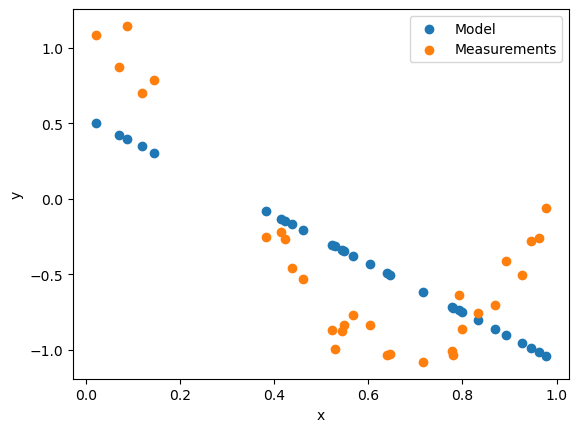

MAE = 0.42
MSE = 0.23
R2 = 0.47


In [3]:
linear_regression = LinearRegression()
linear_regression.fit(X[:, np.newaxis], y)

y_pred = linear_regression.predict(X[:, np.newaxis])

plt.scatter(X[:, np.newaxis], y_pred, label="Model")
plt.scatter(X[:, np.newaxis], y, label="Measurements")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

print(f"MAE = {mean_absolute_error(y, y_pred):.2f}")
print(f"MSE = {mean_squared_error(y, y_pred):.2f}")
print(f"R2 = {r2_score(y, y_pred):.2f}")


Using polynomials we can help our model to capture the function a bit better. Lets put what we did above and the ploynomial creation in a function so we can call it with different degrees.

In [4]:
def linear_regression_with_polynomials_of_degree(degree):
    polynomial_features = PolynomialFeatures(degree=degree, include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline(
        [
            ("polynomial_features", polynomial_features),
            ("linear_regression", linear_regression),
        ]
    )
    pipeline.fit(X[:, np.newaxis], y)

    y_pred = pipeline.predict(X[:, np.newaxis])
    plt.scatter(X[:, np.newaxis], y_pred, label="Model")
    plt.scatter(X[:, np.newaxis], y, label="Original Measurements")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()

    print(f"MAE = {mean_absolute_error(y, y_pred):.2f}")
    print(f"MSE = {mean_squared_error(y, y_pred):.2f}")
    print(f"R2 = {r2_score(y, y_pred):.2f}")

Calling this with degree = 1  leads to the same model as above.

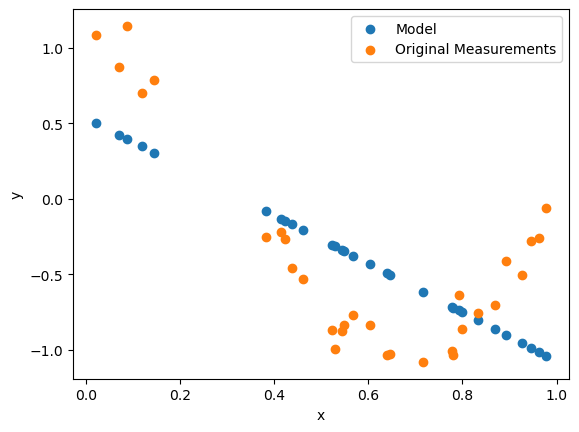

MAE = 0.42
MSE = 0.23
R2 = 0.47


In [5]:
linear_regression_with_polynomials_of_degree(1)

How about degree = 2?
This is looking better, but we are still underfitting, meaning that our model can not grasp the complexity of the true function.

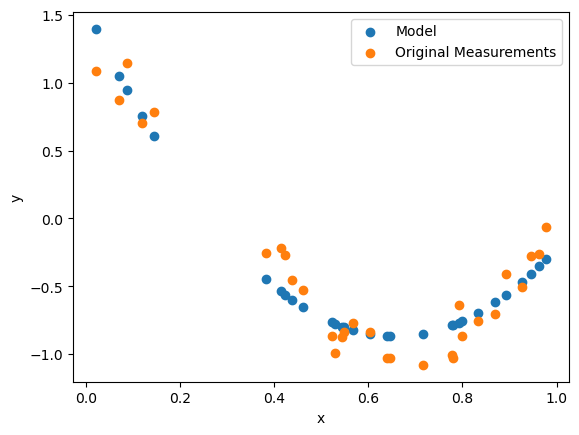

MAE = 0.15
MSE = 0.03
R2 = 0.93


In [6]:
linear_regression_with_polynomials_of_degree(2)

How about degree = 4?

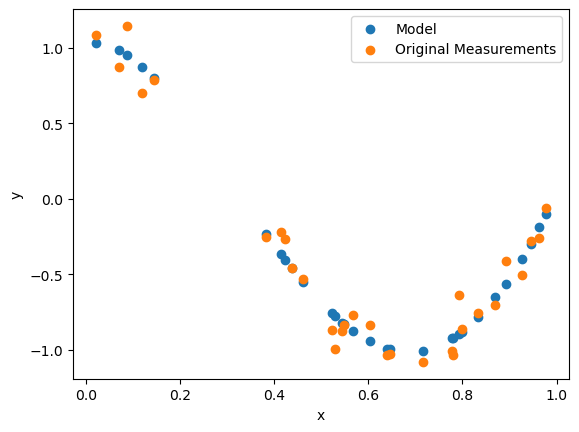

MAE = 0.08
MSE = 0.01
R2 = 0.97


In [7]:
linear_regression_with_polynomials_of_degree(4)


How about degree 16?

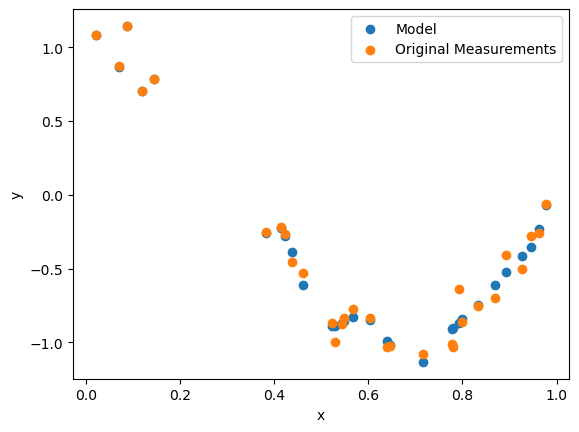

MAE = 0.05
MSE = 0.00
R2 = 0.99


In [8]:
linear_regression_with_polynomials_of_degree(16)


# Reality...
Lets make some new datapoints from the original function

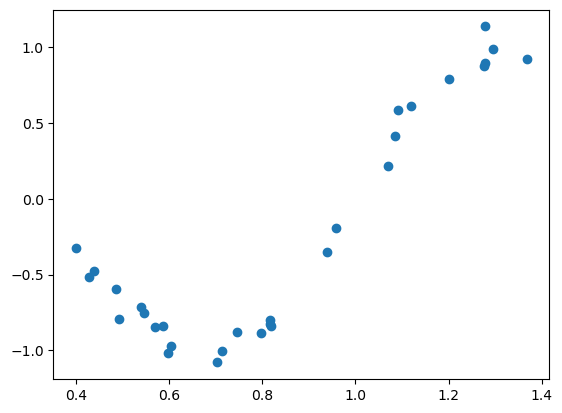

In [9]:
np.random.seed(1)

n_samples = 30

X_new = np.sort(np.random.rand(n_samples)) +.4
y_new = true_fun(X_new) + np.random.randn(n_samples) * 0.1


plt.scatter(X_new, y_new, label="New Measurement")
# plt.plot(np.linspace(0, 1, 1000), true_fun(np.linspace(0, 1, 1000)), label="True function")
plt.show()

Train a regressor on the original datapoints, test it on the new ones

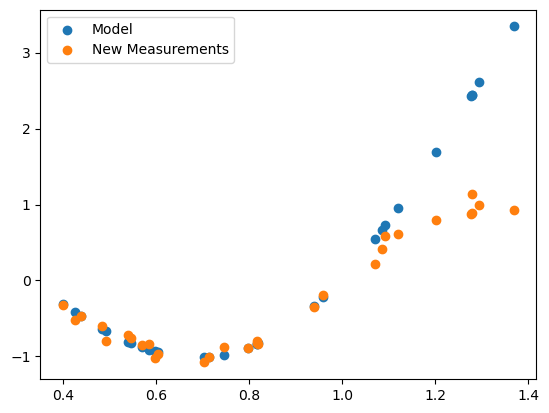

MAE = 0.38
MSE = 0.54
R2 = 0.01


In [10]:
degree = 4
polynomial_features = PolynomialFeatures(degree=degree, include_bias=False)
linear_regression = LinearRegression()
pipeline = Pipeline(
    [
        ("polynomial_features", polynomial_features),
        ("linear_regression", linear_regression),
    ]
)
pipeline.fit(X[:, np.newaxis], y)


y_pred_new = pipeline.predict(X_new[:, np.newaxis])
plt.scatter(X_new[:, np.newaxis], y_pred_new, label="Model")
plt.scatter(X_new[:, np.newaxis], y_new, label="New Measurements")
# plt.xlabel("x")
# plt.ylabel("y")
# plt.xlim(-0.01,1.41)
# plt.ylim(-1.5,2)
plt.legend()
plt.show()

print(f"MAE = {mean_absolute_error(y_new, y_pred_new):.2f}")
print(f"MSE = {mean_squared_error(y_new, y_pred_new):.2f}")
print(f"R2 = {r2_score(y_new, y_pred_new):.2f}")


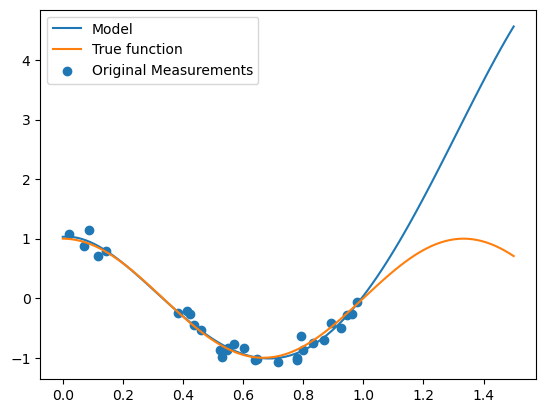

In [11]:
degree = 4
polynomial_features = PolynomialFeatures(degree=degree, include_bias=False)
linear_regression = LinearRegression()
pipeline = Pipeline(
    [
        ("polynomial_features", polynomial_features),
        ("linear_regression", linear_regression),
    ]
)
pipeline.fit(X[:, np.newaxis], y)

X_test = np.linspace(0, 1.5, 100)
y_pred = pipeline.predict(X_test[:, np.newaxis])

plt.plot(X_test[:, np.newaxis], y_pred, label="Model")
plt.plot(X_test, true_fun(X_test), label="True function")
plt.scatter(X[:, np.newaxis], y, label="Original Measurements")
#

# plt.xlabel("x")
# plt.ylabel("y")
plt.legend()
plt.show()
